# Modelado básico: referencias y regresión logística

El objetivo de este notebook es construir una primera comparación antes de probar ensambles. Empiezo con políticas simples y termino con una regresión logística, usando los mismos folds temporales definidos en el notebook 02.

No uso el test final, no busco hiperparámetros y no hago resampling. La regresión funciona como una referencia interpretable para saber cuánto podemos mejorar con una relación lineal y un preprocesamiento razonable.

## 1. Setup

In [41]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, precision_recall_curve, RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.figsize"] = (7, 3.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import TARGET, DEFAULT_DATA_PATH, DEFAULT_PROCESSED_DIR, cargar_datos, convertir_fecha
from src.evaluation import metricas_decision, metricas_probabilidad, mejor_corte_score
from src.features import (
    CATEGORICA_ALTA_LOGISTICA,
    CATEGORICAS_BAJAS_LOGISTICA,
    NUMERICAS_LOGISTICA,
    crear_features_logistica,
)
from src.validation import mascaras_desarrollo_test, mascaras_fold, validar_folds

UMBRAL_ECONOMICO = 0.20
RANDOM_SEED = 42
FOLDS_PATH = DEFAULT_PROCESSED_DIR / "validation_folds.csv"

In [42]:
df = cargar_datos(DEFAULT_DATA_PATH)
fecha = convertir_fecha(df["fecha"])

if not FOLDS_PATH.exists():
    raise FileNotFoundError(
        "No existe validation_folds.csv. Ejecutar primero 02_split_y_validacion.ipynb."
    )

columnas_fecha = ["train_start", "train_end", "validation_start", "validation_end"]
folds = pd.read_csv(FOLDS_PATH, parse_dates=columnas_fecha)
es_desarrollo, es_test = mascaras_desarrollo_test(fecha)
chequeos = validar_folds(fecha, folds, es_test)

print(f"Desarrollo: {es_desarrollo.sum():,} filas")
print(f"Test bloqueado: {es_test.sum():,} filas")
chequeos[["n_train", "n_validacion"]]

Desarrollo: 121,014 filas
Test bloqueado: 28,986 filas


,n_train,n_validacion
fold,,
1,60424,16537
2,76961,20282
3,97243,23771


### Política de umbral y calibración

Todas las decisiones usan el umbral económico fijo de 0,20 derivado de los costos. Como ese corte requiere probabilidades calibradas, reporto Brier y curvas de calibración. La recalibración sólo se conserva si mejora Brier o ganancia en los folds temporales.

No uso SMOTE ni class_weight en esta primera logística. Tenemos miles de fraudes en cada train y necesitamos probabilidades que conserven una interpretación económica. Los pesos de clase pueden cambiar esa interpretación. Se probarán más adelante, y habrá que revisar también la calibración.

## 2. Referencias sin modelo

- **Aprobar todo:** conserva todo el negocio, pero deja pasar todos los fraudes.
- **Rechazar todo:** evita fraudes, pero también elimina toda la ganancia.
- **Regla de score:** dentro de cada train busco el corte de score que habría dejado mayor ganancia y aplico ese corte a la validación siguiente. El corte de score se vuelve a elegir en cada train. No uso el 91 encontrado en el EDA porque ese valor se obtuvo mirando todo el dev set de una sola vez

In [43]:
resultados_politicas = []

for _, fold in folds.iterrows():
    train, validacion = mascaras_fold(fecha, fold)
    y_train = df.loc[train, TARGET]
    y_val = df.loc[validacion, TARGET]
    monto_val = df.loc[validacion, "monto"]

    decisiones = {
        "aprobar_todo": pd.Series(True, index=y_val.index),
        "rechazar_todo": pd.Series(False, index=y_val.index),
    }

    corte_score = mejor_corte_score(
        df.loc[train, "score"], y_train, df.loc[train, "monto"]
    )
    decisiones["regla_score"] = df.loc[validacion, "score"] < corte_score

    for estrategia, aprobar in decisiones.items():
        fila = {
            "fold": int(fold["fold"]),
            "estrategia": estrategia,
            "n_validacion": len(y_val),
            "corte_score": corte_score if estrategia == "regla_score" else np.nan,
        }
        fila.update(metricas_decision(y_val, monto_val, aprobar))
        resultados_politicas.append(fila)

resultados_politicas = pd.DataFrame(resultados_politicas)
resultados_politicas

,fold,estrategia,n_validacion,corte_score,ganancia,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas
0,1,aprobar_todo,16537,NaN,"88,131.9200",1.0000,0.0000,0.0000
1,1,rechazar_todo,16537,NaN,0.0000,0.0000,1.0000,1.0000
2,1,regla_score,16537,98.0000,"89,636.6325",0.9720,0.1540,0.0199
3,2,aprobar_todo,20282,NaN,"101,294.0225",1.0000,0.0000,0.0000
4,2,rechazar_todo,20282,NaN,0.0000,0.0000,1.0000,1.0000
5,2,regla_score,20282,95.0000,"115,400.5475",0.9760,0.1872,0.0142
6,3,aprobar_todo,23771,NaN,"127,601.7175",1.0000,0.0000,0.0000
7,3,rechazar_todo,23771,NaN,0.0000,0.0000,1.0000,1.0000
8,3,regla_score,23771,93.0000,"141,567.6125",0.9666,0.2464,0.0217


Aprobar todo deja una suma de 317.028 sobre todo validación. (En el EDA dejaba 756.781 porque se calculaba sobre todo el dev)

La regla de score supera a aprobar todo en los tres folds, pero el corte elegido en train cambia de 98 a 95 y luego a 93. Usar un corte fijo sin revisarlo podría degradarse con el tiempo.

Rechazar todo deja ganancia cero

## 3. Features para la regresión logística

La logística necesita que las relaciones estén representadas de forma más explícita que en un árbol. Uso las siguientes decisiones, apoyadas en el EDA:

- log1p para monto, c y e, log con signo para f.
- Indicadores de ausencia para b/c, d/m y f/l.
- Indicador e = 0.
- Hora, día de semana y días desde el inicio a partir de fecha.
- One-hot para las categóricas de baja cardinalidad.
- En j, one-hot agrupando dentro de cada train los niveles con menos de 20 apariciones (ver más adelante)
- Imputación por mediana y escalado para las numéricas.

No incluyo k en principio: el EDA la dejó en duda (única por fila, correlación nula con el fraude) sin descartarla, así que en vez de decidirlo a mano lo verifico en la sección 3.3.

Para score preparo dos escenarios, porque todavía no sabemos si está disponible al momento de decidir.

In [44]:
fecha_origen = fecha.min().normalize()
X_sin_score = crear_features_logistica(df, incluir_score=False, fecha_origen=fecha_origen)
X_con_score = crear_features_logistica(df, incluir_score=True, fecha_origen=fecha_origen)

resumen_features = pd.DataFrame({
    "escenario": ["sin score", "con score"],
    "n_columnas_antes_del_encoding": [X_sin_score.shape[1], X_con_score.shape[1]],
    "incluye_score": [False, True],
})
resumen_features

,escenario,n_columnas_antes_del_encoding,incluye_score
0,sin score,22,False
1,con score,23,True


### 3.1. Por qué imputamos con la mediana

La logística imputa las numéricas con la mediana aprendida en cada train y conserva indicadores para los patrones de ausencia b/c, d/m y f/l. En las categóricas, los faltantes se representan como una categoría. Para este baseline no se justifican métodos de imputación más complejos.

### 3.2. Qué hacemos con j

j tiene 7.898 categorías y más de la mitad aparece menos de cinco veces. Un one-hot completo produciría coeficientes aprendidos con muy pocos casos.

Dentro de cada train, los niveles con al menos 20 apariciones conservan su columna. Los menos frecuentes y los nuevos se agrupan como infrecuentes. El valor 20 es una regla inicial, no un hiperparámetro optimizado. Más adelante se compara contra target encoding.

La agrupación y el encoding se ajustan dentro del pipeline para no usar información de validación.

In [45]:
from src.modeling import crear_pipeline_logistica

### 3.3. Conviene incluir k?

Para cada fold ajusto la logística con y sin k sobre el mismo train y comparo la ganancia de validación bajo el umbral de 20%, además del coeficiente que recibe k. Un modelo lineal solo puede aprovechar una relación monótona: si no hay señal, k debería quedar con coeficiente cercano a cero y no mover la ganancia. La pregunta de si un modelo más expresivo la aprovecharía vía interacción queda para los árboles del próximo notebook, que sí arman cruces por su cuenta.

In [46]:
ablacion_k = []
X_con_score_k = X_con_score.copy()
X_con_score_k["k"] = df["k"]

for _, fold in folds.iterrows():
    train, validacion = mascaras_fold(fecha, fold)
    y_val = df.loc[validacion, TARGET]
    monto_val = df.loc[validacion, "monto"]

    for etiqueta, X_datos, incluir_k in [
        ("sin k", X_con_score, False),
        ("con k", X_con_score_k, True),
    ]:
        pipeline = crear_pipeline_logistica(incluir_score=True, incluir_k=incluir_k)
        pipeline.fit(X_datos.loc[train], df.loc[train, TARGET])
        probabilidad = pipeline.predict_proba(X_datos.loc[validacion])[:, 1]
        aprobar = probabilidad < UMBRAL_ECONOMICO

        fila = {"fold": int(fold["fold"]), "variante": etiqueta}
        fila.update(metricas_decision(y_val, monto_val, aprobar))
        fila.update(metricas_probabilidad(y_val, probabilidad))
        if incluir_k:
            nombres = pipeline.named_steps["preprocesamiento"].get_feature_names_out()
            indice_k = list(nombres).index("numericas__k")
            fila["coef_k"] = pipeline.named_steps["modelo"].coef_[0][indice_k]
        ablacion_k.append(fila)

ablacion_k = pd.DataFrame(ablacion_k)
resumen_ablacion_k = (
    ablacion_k.groupby("variante")
    .agg(
        ganancia=("ganancia", "sum"),
        pr_auc=("pr_auc", "mean"),
        coef_k_medio=("coef_k", "mean"),
    )
)
resumen_ablacion_k

,ganancia,pr_auc,coef_k_medio
variante,,,
con k,"420,351.5525",0.3937,0.0122
sin k,"420,515.7650",0.3943,NaN


k recibe un coeficiente medio de 0,012, dos órdenes de magnitud por debajo de las features que sí pesan, y agregarla no mejora nada: la ganancia baja apenas y el PR-AUC tampoco sube. Queda excluida por evidencia. Si un modelo más expresivo pudiera aprovecharla mediante interacciones se responde con los árboles del próximo notebook.

## 4. Validación de la regresión logística

Entreno un pipeline nuevo en cada fold y apruebo cuando la probabilidad estimada de fraude es menor a 20%, el umbral derivado de la función de ganancia. No optimizo ese corte con las validaciones en esta etapa.

In [47]:
escenarios = {
    "logistica_sin_score": (X_sin_score, False),
    "logistica_con_score": (X_con_score, True),
}

resultados_logistica = []
predicciones_oof = []
coeficientes_folds = []

for escenario, (X, incluir_score) in escenarios.items():
    for _, fold in folds.iterrows():
        train, validacion = mascaras_fold(fecha, fold)
        pipeline = crear_pipeline_logistica(incluir_score)
        pipeline.fit(X.loc[train], df.loc[train, TARGET])

        probabilidad = pd.Series(
            pipeline.predict_proba(X.loc[validacion])[:, 1],
            index=df.index[validacion],
            name="probabilidad_fraude",
        )
        aprobar = probabilidad < UMBRAL_ECONOMICO
        y_val = df.loc[validacion, TARGET]
        monto_val = df.loc[validacion, "monto"]

        fila = {"fold": int(fold["fold"]), "estrategia": escenario}
        fila.update(metricas_decision(y_val, monto_val, aprobar))
        fila.update(metricas_probabilidad(y_val, probabilidad))
        fila["iteraciones"] = int(pipeline.named_steps["modelo"].n_iter_[0])
        resultados_logistica.append(fila)

        nombres_features = pipeline.named_steps["preprocesamiento"].get_feature_names_out()
        coeficientes_folds.append(pd.DataFrame({
            "fold": int(fold["fold"]),
            "estrategia": escenario,
            "feature": nombres_features,
            "coeficiente": pipeline.named_steps["modelo"].coef_[0],
        }))

        predicciones_oof.append(pd.DataFrame({
            "fold": int(fold["fold"]),
            "estrategia": escenario,
            "target": y_val,
            "monto": monto_val,
            "probabilidad_fraude": probabilidad,
        }))

resultados_logistica = pd.DataFrame(resultados_logistica)
predicciones_oof = pd.concat(predicciones_oof).sort_index()
coeficientes_folds = pd.concat(coeficientes_folds, ignore_index=True)
resultados_logistica

,fold,estrategia,ganancia,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas,roc_auc,pr_auc,brier,prevalencia,pr_auc_norm,brier_skill,iteraciones
0,1,logistica_sin_score,"116,929.9300",0.9387,0.4180,0.0383,0.8569,0.3888,0.0455,0.0605,0.3495,0.1993,90
1,2,logistica_sin_score,"133,413.2525",0.9203,0.4628,0.0568,0.8389,0.3383,0.0445,0.0564,0.2988,0.1627,96
2,3,logistica_sin_score,"163,352.5850",0.9258,0.4694,0.0524,0.8434,0.3439,0.0413,0.0522,0.3077,0.1663,123
3,1,logistica_con_score,"118,624.8550",0.9356,0.4750,0.0380,0.8629,0.4291,0.0437,0.0605,0.3924,0.2301,89
4,2,logistica_con_score,"136,923.5675",0.9233,0.4733,0.0530,0.8399,0.3732,0.0430,0.0564,0.3358,0.1909,108
5,3,logistica_con_score,"164,967.3425",0.9271,0.4911,0.0498,0.8448,0.3805,0.0399,0.0522,0.3463,0.1949,108


ROC-AUC y PR-AUC miden el ordenamiento del riesgo. PR-AUC resulta especialmente útil por el desbalance, pero ninguna evalúa el valor de las probabilidades.

Brier mide el error cuadrático de las probabilidades:

$$\text{Brier} = \frac{1}{N}\sum_{i=1}^{N}(p_i-y_i)^2$$

Menor es mejor. Predecir siempre la prevalencia obtiene aproximadamente 0,0475 en estos datos.

Como la decisión usa un umbral de 0,20, Brier permite acompañar el chequeo de calibración. La métrica principal continúa siendo la ganancia.

### 4.1. Curvas ROC y Precision-Recall

Uno las predicciones de las tres validaciones para ver las curvas completas. ROC muestra la relación entre fraudes detectados y falsas alarmas (FPR). Precision-Recall se concentra en la clase fraude y es más exigente cuando esa clase es minoritaria.

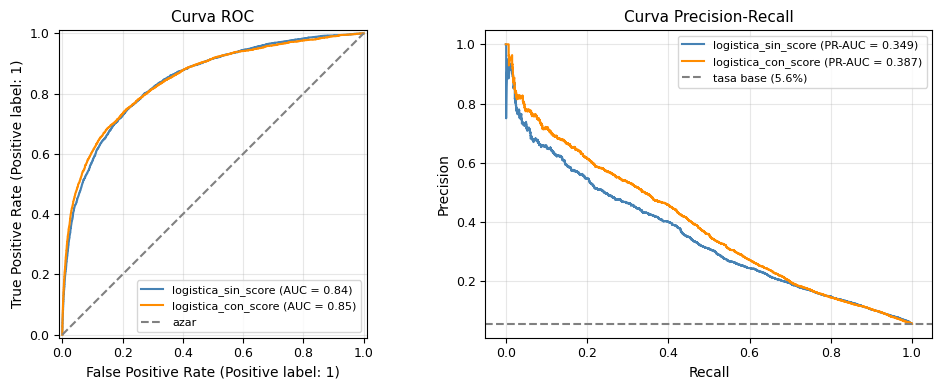

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for estrategia, color in [
    ("logistica_sin_score", "steelblue"),
    ("logistica_con_score", "darkorange"),
]:
    datos = predicciones_oof.query("estrategia == @estrategia")
    RocCurveDisplay.from_predictions(
        datos["target"],
        datos["probabilidad_fraude"],
        name=estrategia,
        ax=axes[0],
        curve_kwargs={"color": color},
    )
    precision, recall, _ = precision_recall_curve(
        datos["target"], datos["probabilidad_fraude"]
    )
    pr_auc = auc(recall, precision)
    axes[1].plot(
        recall,
        precision,
        label=f"{estrategia} (PR-AUC = {pr_auc:.3f})",
        color=color,
    )

axes[0].plot([0, 1], [0, 1], ls="--", color="gray", label="azar")
tasa_base_validacion = predicciones_oof.query(
    "estrategia == 'logistica_sin_score'"
)["target"].mean()
axes[1].axhline(
    tasa_base_validacion,
    ls="--",
    color="gray",
    label=f"tasa base ({tasa_base_validacion:.1%})",
)

axes[0].set_title("Curva ROC", fontsize=11)
axes[1].set_title("Curva Precision-Recall", fontsize=11)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
for ax in axes:
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

Las dos versiones separan el fraude mejor que el azar. Agregar score produce una mejora pequeña en ROC, pero una diferencia más visible en Precision-Recall

## 5. Qué variables pesan en la regresión

Se analiza la importancia de coeficientes.

Como las numéricas están escaladas, sus magnitudes son más comparables entre sí. En las categóricas, cada barra corresponde a un nivel one-hot. Promedio los coeficientes entre folds y muestro únicamente columnas presentes en los tres modelos, para evitar destacar una categoría que apareció de forma aislada.

j tiene cientos de columnas one-hot y sus coeficientes suelen ser los más grandes, incluso separando "categóricas de baja cardinalidad" de "numéricas" pueden tapar a variables como score. Por eso separo el gráfico en tres, cada una con su top 12: numéricas (incluido score cuando corresponde), categóricas de baja cardinalidad y categorías de j.

Las barras de error son el desvío de cada coeficiente entre folds: cuanto más largas, menos estable es ese coeficiente (suele ser señal de colinealidad).

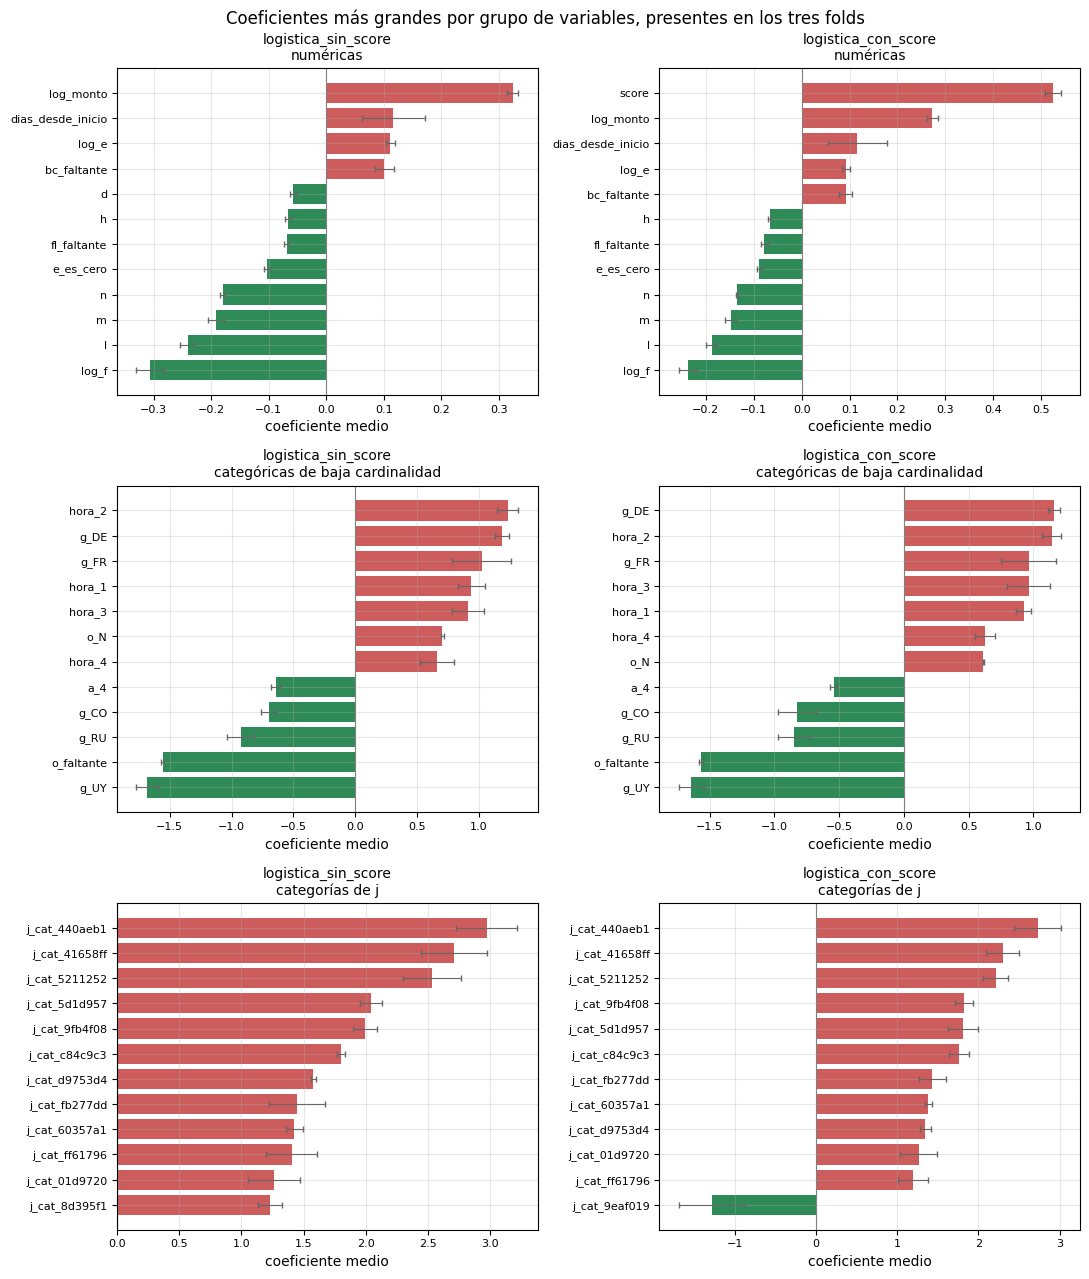

In [49]:
coeficientes_estables = (
    coeficientes_folds.groupby(["estrategia", "feature"])
    .agg(
        n_folds=("fold", "nunique"),
        coeficiente_medio=("coeficiente", "mean"),
        magnitud_media=("coeficiente", lambda s: s.abs().mean()),
        variacion=("coeficiente", "std"),
    )
    .reset_index()
    .query("n_folds == 3")
)


def _asignar_grupo(feature):
    if feature.startswith("numericas__"):
        return "numéricas"
    if feature.startswith("categoricas__"):
        return "categóricas de baja cardinalidad"
    return "categorías de j"


coeficientes_estables["grupo"] = coeficientes_estables["feature"].map(_asignar_grupo)
coeficientes_estables["feature_limpia"] = (
    coeficientes_estables["feature"]
    .str.replace(r"^(numericas|categoricas|j)__", "", regex=True)
)

grupos = [
    "numéricas",
    "categóricas de baja cardinalidad",
    "categorías de j",
]
fig, axes = plt.subplots(len(grupos), len(escenarios), figsize=(11, 13))
for fila, grupo in enumerate(grupos):
    for columna, estrategia in enumerate(escenarios):
        ax = axes[fila, columna]
        top = (
            coeficientes_estables.query("estrategia == @estrategia and grupo == @grupo")
            .nlargest(12, "magnitud_media")
            .sort_values("coeficiente_medio")
        )
        colores = np.where(top["coeficiente_medio"] > 0, "indianred", "seagreen")
        ax.barh(top["feature_limpia"], top["coeficiente_medio"], xerr=top["variacion"],
                color=colores, error_kw={"ecolor": "0.4", "elinewidth": 0.8, "capsize": 2})
        ax.axvline(0, color="gray", linewidth=0.8)
        ax.set_title(f"{estrategia}\n{grupo}", fontsize=10)
        ax.set_xlabel("coeficiente medio")
        ax.tick_params(labelsize=8)
fig.suptitle("Coeficientes más grandes por grupo de variables, presentes en los tres folds", fontsize=12)
plt.tight_layout()
plt.show()

Los coeficientes más grandes corresponden principalmente a categorías específicas de j que empujan la predicción hacia fraude. También reaparecen señales del EDA: o = faltante y g = UY empujan hacia operación legítima, mientras que o = N lo hace hacia fraude. Cuando se agrega score, su coeficiente es positivo, como se esperaba.

## 6. Comparación económica

In [50]:
resultados = pd.concat(
    [resultados_politicas, resultados_logistica],
    ignore_index=True,
    sort=False,
)

resumen_resultados = (
    resultados.groupby("estrategia")
    .agg(
        ganancia_total=("ganancia", "sum"),
        ganancia_media=("ganancia", "mean"),
        variacion_ganancia=("ganancia", "std"),
        tasa_aprobacion=("tasa_aprobacion", "mean"),
        fraudes_rechazados=("fraudes_rechazados", "mean"),
        legitimas_rechazadas=("legitimas_rechazadas", "mean"),
        pr_auc=("pr_auc", "mean"),
        roc_auc=("roc_auc", "mean"),
        brier=("brier", "mean"),
    )
    .sort_values("ganancia_total", ascending=False)
)

ganancia_base = resumen_resultados.loc["aprobar_todo", "ganancia_total"]
resumen_resultados["mejora_sobre_aprobar_todo"] = (
    resumen_resultados["ganancia_total"] / ganancia_base - 1
)

resultados.to_csv(
    DEFAULT_PROCESSED_DIR / "resultados_modelado_basico.csv",
    index=False,
)
resumen_resultados

,ganancia_total,ganancia_media,variacion_ganancia,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas,pr_auc,roc_auc,brier,mejora_sobre_aprobar_todo
estrategia,,,,,,,,,,
logistica_con_score,"420,515.7650","140,171.9217","23,341.3879",0.9287,0.4798,0.0469,0.3943,0.8492,0.0422,0.3264
logistica_sin_score,"413,695.7675","137,898.5892","23,534.1116",0.9283,0.4501,0.0492,0.3570,0.8464,0.0438,0.3049
regla_score,"346,604.7925","115,534.9308","25,965.7508",0.9715,0.1959,0.0186,NaN,NaN,NaN,0.0933
aprobar_todo,"317,027.6600","105,675.8867","20,096.4370",1.0000,0.0000,0.0000,NaN,NaN,NaN,0.0000
rechazar_todo,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,NaN,NaN,NaN,-1.0000


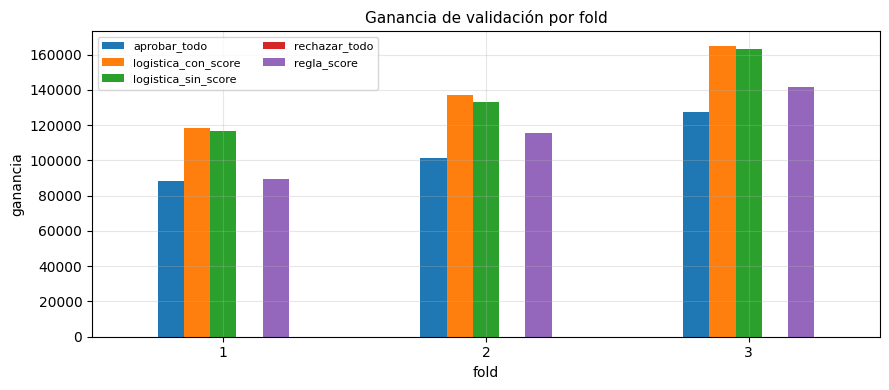

In [51]:
ganancia_por_fold = resultados.pivot(
    index="fold", columns="estrategia", values="ganancia"
)

ax = ganancia_por_fold.plot.bar(figsize=(9, 4), rot=0)
ax.set_xlabel("fold")
ax.set_ylabel("ganancia")
ax.set_title("Ganancia de validación por fold", fontsize=11)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Las dos regresiones superan a las políticas simples en los tres folds. 

La mejora de agregar score existe, pero es chica. Esto es importante porque deja una alternativa competitiva si no podemos confirmar que score está disponible al decidir.

Con el umbral de 20%, ambas logísticas aprueban cerca del 93% de las operaciones.

## 7. Las probabilidades representan el riesgo observado?

Agrupo las predicciones de validación en diez grupos de igual tamaño y comparo la probabilidad media con el fraude observado. Sobre la diagonal ambas coinciden. Por encima, el modelo subestima el riesgo y, por debajo, lo sobreestima. Esto permite revisar la escala de las probabilidades alrededor del umbral de 0,20.

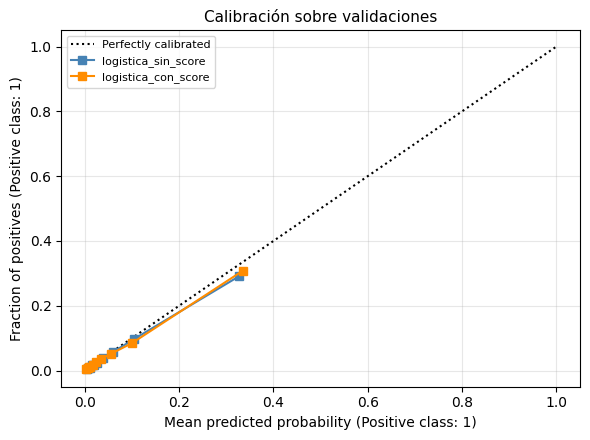

In [52]:
fig, ax = plt.subplots(figsize=(6, 4.5))

for estrategia, color in [
    ("logistica_sin_score", "steelblue"),
    ("logistica_con_score", "darkorange"),
]:
    datos = predicciones_oof.query("estrategia == @estrategia")
    CalibrationDisplay.from_predictions(
        datos["target"],
        datos["probabilidad_fraude"],
        n_bins=10,
        strategy="quantile",
        name=estrategia,
        ax=ax,
        color=color,
    )

ax.set_title("Calibración sobre validaciones", fontsize=11)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Las curvas se mantienen cerca de la diagonal en la mayor parte del rango. En el grupo de mayor riesgo, ambas regresiones tienden a predecir una probabilidad algo diferente a la tasa. El umbral de 20% es una referencia razonable para este baseline, pero antes de una decisión final conviene revisar calibración y umbral junto con los modelos de árboles.

## 8. Conviene target encoding para j?

El one-hot agrupado evita crear columnas con pocos casos, pero también borra diferencias entre categorías raras. Como j concentra varios de los coeficientes más grandes de la logística, comparo esta solución con target encoding.

Target encoding reemplaza cada categoría por la tasa de fraude aprendida en el train. Se usa cross-fitting interno para que cada fila no se codifique con su propio target. Los niveles nuevos reciben la media global del train y el resto del pipeline permanece igual.

In [53]:
from sklearn.preprocessing import TargetEncoder


def crear_pipeline_logistica_target_j(incluir_score):
    columnas_numericas = NUMERICAS_LOGISTICA.copy()
    if incluir_score:
        columnas_numericas.append("score")

    pipeline_numericas = Pipeline([
        ("imputacion", SimpleImputer(strategy="median")),
        ("escalado", StandardScaler()),
    ])

    pipeline_categoricas = Pipeline([
        ("imputacion", SimpleImputer(strategy="constant", fill_value="faltante")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore")),
    ])

    pipeline_j = Pipeline([
        ("imputacion", SimpleImputer(strategy="constant", fill_value="faltante")),
        ("target_encoding", TargetEncoder(target_type="binary", random_state=RANDOM_SEED)),
    ])

    preprocesamiento = ColumnTransformer([
        ("numericas", pipeline_numericas, columnas_numericas),
        ("categoricas", pipeline_categoricas, CATEGORICAS_BAJAS_LOGISTICA),
        ("j", pipeline_j, CATEGORICA_ALTA_LOGISTICA),
    ])

    modelo = LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=500,
        random_state=RANDOM_SEED,
    )

    return Pipeline([
        ("preprocesamiento", preprocesamiento),
        ("modelo", modelo),
    ])

In [54]:
resultados_target_j = []
predicciones_target_j = []

for escenario, (X, incluir_score) in escenarios.items():
    nombre_escenario = escenario.replace("logistica_", "logistica_target_j_")
    for _, fold in folds.iterrows():
        train, validacion = mascaras_fold(fecha, fold)
        pipeline = crear_pipeline_logistica_target_j(incluir_score)
        pipeline.fit(X.loc[train], df.loc[train, TARGET])

        probabilidad = pd.Series(
            pipeline.predict_proba(X.loc[validacion])[:, 1],
            index=df.index[validacion],
            name="probabilidad_fraude",
        )
        aprobar = probabilidad < UMBRAL_ECONOMICO
        y_val = df.loc[validacion, TARGET]
        monto_val = df.loc[validacion, "monto"]

        fila = {"fold": int(fold["fold"]), "estrategia": nombre_escenario}
        fila.update(metricas_decision(y_val, monto_val, aprobar))
        fila.update(metricas_probabilidad(y_val, probabilidad))
        resultados_target_j.append(fila)

        predicciones_target_j.append(pd.DataFrame({
            "fold": int(fold["fold"]),
            "estrategia": nombre_escenario,
            "target": y_val,
            "monto": monto_val,
            "probabilidad_fraude": probabilidad,
        }))

resultados_target_j = pd.DataFrame(resultados_target_j)
predicciones_target_j = pd.concat(predicciones_target_j).sort_index()
resultados_target_j

,fold,estrategia,ganancia,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas,roc_auc,pr_auc,brier,prevalencia,pr_auc_norm,brier_skill
0,1,logistica_target_j_sin_score,"116,652.3375",0.9401,0.4170,0.0369,0.8581,0.3818,0.0458,0.0605,0.3420,0.1945
1,2,logistica_target_j_sin_score,"131,965.6750",0.9236,0.4549,0.0538,0.8427,0.3519,0.0440,0.0564,0.3132,0.1731
2,3,logistica_target_j_sin_score,"165,361.9000",0.9263,0.4630,0.0522,0.8446,0.3356,0.0413,0.0522,0.2990,0.1656
3,1,logistica_target_j_con_score,"115,398.0600",0.9359,0.4640,0.0384,0.8642,0.4262,0.0439,0.0605,0.3893,0.2271
4,2,logistica_target_j_con_score,"135,429.6375",0.9261,0.4768,0.0498,0.8419,0.3901,0.0424,0.0564,0.3537,0.2022
5,3,logistica_target_j_con_score,"164,772.8350",0.9265,0.4903,0.0506,0.8443,0.3811,0.0397,0.0522,0.3470,0.1989


In [55]:
comparacion_encoding_j = (
    pd.concat([resultados_logistica, resultados_target_j], ignore_index=True, sort=False)
    .groupby("estrategia")
    .agg(
        ganancia_total=("ganancia", "sum"),
        tasa_aprobacion=("tasa_aprobacion", "mean"),
        fraudes_rechazados=("fraudes_rechazados", "mean"),
        legitimas_rechazadas=("legitimas_rechazadas", "mean"),
        pr_auc=("pr_auc", "mean"),
        roc_auc=("roc_auc", "mean"),
        brier=("brier", "mean"),
    )
    .sort_values("ganancia_total", ascending=False)
)
comparacion_encoding_j

,ganancia_total,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas,pr_auc,roc_auc,brier
estrategia,,,,,,,
logistica_con_score,"420,515.7650",0.9287,0.4798,0.0469,0.3943,0.8492,0.0422
logistica_target_j_con_score,"415,600.5325",0.9295,0.4771,0.0462,0.3991,0.8501,0.0420
logistica_target_j_sin_score,"413,979.9125",0.9300,0.4450,0.0476,0.3564,0.8485,0.0437
logistica_sin_score,"413,695.7675",0.9283,0.4501,0.0492,0.3570,0.8464,0.0438


Con score, target encoding mejora levemente el ordenamiento y Brier, pero deja menos ganancia. Sin score, ambas codificaciones quedan prácticamente empatadas. Como Brier y la tasa de aprobación son similares, no aparece un corrimiento importante de calibración. Mantengo el one-hot agrupado porque la ganancia es la métrica principal.

## 9. ¿Conviene un rebalanceo de clases?

Aunque el fraude representa cerca del 5%, cada train contiene miles de positivos. Pruebo **class_weight="balanced"** para medir si aporta algo más.

Los pesos pueden cambiar tanto el ordenamiento como la escala de las probabilidades, por lo que comparar únicamente al umbral de 0,20 sería incompleto. Primero evalúo las probabilidades crudas, después reviso el ordenamiento y finalmente recalibro usando sólo datos del train antes de volver a aplicar el mismo umbral. El encoding, los folds y el resto del pipeline permanecen iguales.

In [56]:
def crear_pipeline_logistica_balanceada(incluir_score):
    columnas_numericas = NUMERICAS_LOGISTICA.copy()
    if incluir_score:
        columnas_numericas.append("score")

    pipeline_numericas = Pipeline([
        ("imputacion", SimpleImputer(strategy="median")),
        ("escalado", StandardScaler()),
    ])

    pipeline_categoricas = Pipeline([
        ("imputacion", SimpleImputer(strategy="constant", fill_value="faltante")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore")),
    ])

    pipeline_j = Pipeline([
        ("imputacion", SimpleImputer(strategy="constant", fill_value="faltante")),
        ("one_hot", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=20,
        )),
    ])

    preprocesamiento = ColumnTransformer([
        ("numericas", pipeline_numericas, columnas_numericas),
        ("categoricas", pipeline_categoricas, CATEGORICAS_BAJAS_LOGISTICA),
        ("j", pipeline_j, CATEGORICA_ALTA_LOGISTICA),
    ])

    modelo = LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=500,
        random_state=RANDOM_SEED,
        class_weight="balanced",
    )

    return Pipeline([
        ("preprocesamiento", preprocesamiento),
        ("modelo", modelo),
    ])

In [57]:
resultados_balanceado = []
predicciones_balanceado = []

for escenario, (X, incluir_score) in escenarios.items():
    nombre_escenario = escenario.replace("logistica_", "logistica_balanceada_")
    for _, fold in folds.iterrows():
        train, validacion = mascaras_fold(fecha, fold)
        pipeline = crear_pipeline_logistica_balanceada(incluir_score)
        pipeline.fit(X.loc[train], df.loc[train, TARGET])

        probabilidad = pd.Series(
            pipeline.predict_proba(X.loc[validacion])[:, 1],
            index=df.index[validacion],
            name="probabilidad_fraude",
        )
        aprobar = probabilidad < UMBRAL_ECONOMICO
        y_val = df.loc[validacion, TARGET]
        monto_val = df.loc[validacion, "monto"]

        fila = {"fold": int(fold["fold"]), "estrategia": nombre_escenario}
        fila.update(metricas_decision(y_val, monto_val, aprobar))
        fila.update(metricas_probabilidad(y_val, probabilidad))
        resultados_balanceado.append(fila)

        predicciones_balanceado.append(pd.DataFrame({
            "fold": int(fold["fold"]),
            "estrategia": nombre_escenario,
            "target": y_val,
            "monto": monto_val,
            "probabilidad_fraude": probabilidad,
        }))

resultados_balanceado = pd.DataFrame(resultados_balanceado)
predicciones_balanceado = pd.concat(predicciones_balanceado).sort_index()
resultados_balanceado

,fold,estrategia,ganancia,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas,roc_auc,pr_auc,brier,prevalencia,pr_auc_norm,brier_skill
0,1,logistica_balanceada_sin_score,"49,318.0575",0.4119,0.9480,0.5650,0.8481,0.3660,0.1548,0.0605,0.3252,-1.7255
1,2,logistica_balanceada_sin_score,"51,069.7200",0.3797,0.9256,0.6020,0.8294,0.3205,0.1740,0.0564,0.2799,-2.2728
2,3,logistica_balanceada_sin_score,"62,294.1925",0.3804,0.9388,0.6020,0.8392,0.3307,0.1707,0.0522,0.2938,-2.4480
3,1,logistica_balanceada_con_score,"51,981.4125",0.4310,0.9420,0.5450,0.8549,0.3927,0.1519,0.0605,0.3536,-1.6736
4,2,logistica_balanceada_con_score,"58,790.5450",0.4199,0.9204,0.5598,0.8341,0.3455,0.1647,0.0564,0.3064,-2.0972
5,3,logistica_balanceada_con_score,"68,056.6925",0.4060,0.9308,0.5754,0.8422,0.3526,0.1657,0.0522,0.3169,-2.3457


In [58]:
comparacion_balanceo = (
    pd.concat([resultados_logistica, resultados_balanceado], ignore_index=True, sort=False)
    .groupby("estrategia")
    .agg(
        ganancia_total=("ganancia", "sum"),
        tasa_aprobacion=("tasa_aprobacion", "mean"),
        fraudes_rechazados=("fraudes_rechazados", "mean"),
        legitimas_rechazadas=("legitimas_rechazadas", "mean"),
        pr_auc=("pr_auc", "mean"),
        roc_auc=("roc_auc", "mean"),
        brier=("brier", "mean"),
    )
    .sort_values("ganancia_total", ascending=False)
)
comparacion_balanceo

,ganancia_total,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas,pr_auc,roc_auc,brier
estrategia,,,,,,,
logistica_con_score,"420,515.7650",0.9287,0.4798,0.0469,0.3943,0.8492,0.0422
logistica_sin_score,"413,695.7675",0.9283,0.4501,0.0492,0.3570,0.8464,0.0438
logistica_balanceada_con_score,"178,828.6500",0.4190,0.9310,0.5601,0.3636,0.8437,0.1608
logistica_balanceada_sin_score,"162,681.9700",0.3907,0.9375,0.5897,0.3390,0.8389,0.1665


### 9.1. Las probabilidades balanceadas siguen siendo interpretables?

Repito el chequeo de calibración de la sección 7 comparando la logística de referencia (sin score) contra su versión con **class_weight="balanced"**. Si el rebalanceo corre las probabilidades lejos de la tasa real, la curva balanceada debería alejarse de la diagonal, sobre todo cerca del 20% que usamos como corte.

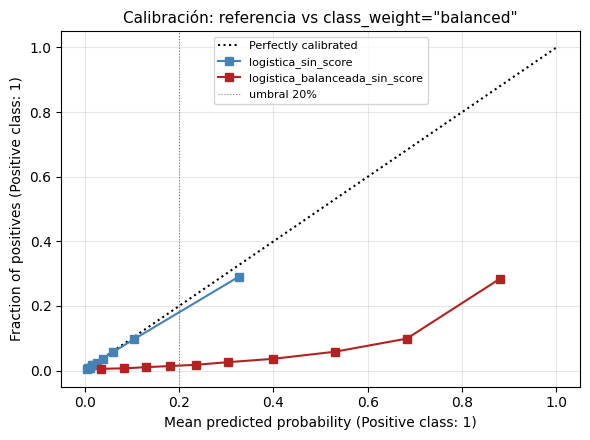

In [59]:
fig, ax = plt.subplots(figsize=(6, 4.5))

comparaciones_calibracion = [
    ("logistica_sin_score", predicciones_oof, "steelblue"),
    ("logistica_balanceada_sin_score", predicciones_balanceado, "firebrick"),
]

for estrategia, fuente, color in comparaciones_calibracion:
    datos = fuente.query("estrategia == @estrategia")
    CalibrationDisplay.from_predictions(
        datos["target"],
        datos["probabilidad_fraude"],
        n_bins=10,
        strategy="quantile",
        name=estrategia,
        ax=ax,
        color=color,
    )

ax.axvline(UMBRAL_ECONOMICO, ls=":", color="gray", linewidth=0.8, label="umbral 20%")
ax.set_title("Calibración: referencia vs class_weight=\"balanced\"", fontsize=11)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Con **class_weight="balanced"** caen la aprobación y la ganancia al umbral de 0,20. Brier empeora de 0,042 a 0,16, lo que muestra un corrimiento en la escala de las probabilidades. El ordenamiento tampoco mejora: PR-AUC baja de 0,3943 a 0,3636. Como recalibrar es una transformación monótona, no puede subir el AUC. Sólo puede corregir la escala de las probabilidades, no su ordenamiento.

### 9.2. Recalibrar el modelo balanceado

Dentro de cada fold entreno el modelo con el primer 75% temporal del train y ajusto un calibrador sigmoide sobre el 25% restante. Luego aplico la corrección a validación y decido al mismo umbral de 0,20. Así la calibración se aprende sin usar la validación y el corte conserva su interpretación económica.

In [60]:
from src.evaluation import ajustar_calibrador_sigmoide, aplicar_calibrador

resultados_recalibrado = []
for _, fold in folds.iterrows():
    train, validacion = mascaras_fold(fecha, fold)
    y_val = df.loc[validacion, TARGET]
    monto_val = df.loc[validacion, "monto"]

    # Corte temporal dentro del train: ultimo 25% por fecha como tramo de calibracion.
    corte_calibracion = fecha.loc[train].quantile(0.75)
    ajuste = train & (fecha <= corte_calibracion)
    calibracion = train & (fecha > corte_calibracion)

    # Referencia sin balanceo, entrenada en todo el train.
    referencia = crear_pipeline_logistica(incluir_score=True)
    referencia.fit(X_con_score.loc[train], df.loc[train, TARGET])
    p_referencia = referencia.predict_proba(X_con_score.loc[validacion])[:, 1]

    # Balanceado entrenado en el tramo de ajuste; calibrador en el tramo reservado.
    balanceado = crear_pipeline_logistica_balanceada(incluir_score=True)
    balanceado.fit(X_con_score.loc[ajuste], df.loc[ajuste, TARGET])
    p_balanceado = balanceado.predict_proba(X_con_score.loc[validacion])[:, 1]

    calibrador = ajustar_calibrador_sigmoide(
        balanceado.predict_proba(X_con_score.loc[calibracion])[:, 1],
        df.loc[calibracion, TARGET],
    )
    p_balanceado_recalibrado = aplicar_calibrador(calibrador, p_balanceado)

    for variante, probabilidad in [
        ("referencia", p_referencia),
        ("balanceado_crudo", p_balanceado),
        ("balanceado_recalibrado", p_balanceado_recalibrado),
    ]:
        aprobar = probabilidad < UMBRAL_ECONOMICO
        fila = {"fold": int(fold["fold"]), "variante": variante}
        fila.update(metricas_decision(y_val, monto_val, aprobar))
        fila.update(metricas_probabilidad(y_val, probabilidad))
        resultados_recalibrado.append(fila)

resultados_recalibrado = pd.DataFrame(resultados_recalibrado)
resumen_recalibrado = (
    resultados_recalibrado.groupby("variante")
    .agg(
        ganancia=("ganancia", "sum"),
        tasa_aprobacion=("tasa_aprobacion", "mean"),
        legitimas_rechazadas=("legitimas_rechazadas", "mean"),
        roc_auc=("roc_auc", "mean"),
        pr_auc=("pr_auc", "mean"),
        brier=("brier", "mean"),
    )
    .reindex(["referencia", "balanceado_crudo", "balanceado_recalibrado"])
)
resumen_recalibrado

,ganancia,tasa_aprobacion,legitimas_rechazadas,roc_auc,pr_auc,brier
variante,,,,,,
referencia,"420,515.7650",0.9287,0.0469,0.8492,0.3943,0.0422
balanceado_crudo,"191,807.1825",0.4522,0.5258,0.8394,0.3502,0.1503
balanceado_recalibrado,"414,584.6350",0.9371,0.0415,0.8394,0.3502,0.0439


Recalibrar eleva la ganancia de 191.807 a 414.585 y reduce Brier de 0,150 a 0,044, por lo que la caída inicial provenía principalmente de la escala. El valor crudo difiere de la sección anterior porque este modelo se entrena con el 75% del train.

Aun recalibrado, queda por debajo de la referencia de 420.516. PR-AUC permanece en 0,3502, frente a 0,3943 de la referencia. Como no mejora el ordenamiento ni la ganancia final, descarto el rebalanceo.

## 10. Conclusiones

1. El mejor corte de score cambia entre folds, por lo que la regla encontrada sobre todo desarrollo no es estable.
2. La regresión logística supera aprobar todo y la regla basada solamente en score.
3. El escenario sin score conserva gran parte de la ganancia, por lo que continúan ambas alternativas.
4. One-hot agrupado deja más ganancia que target encoding. El rebalanceo empeora el ordenamiento y tampoco mejora la ganancia después de recalibrar.
5. Las probabilidades son razonables para aplicar el umbral de 0,20, aunque el grupo de mayor riesgo muestra algo de descalibración.

El siguiente paso es comparar modelos de árboles sobre los mismos folds.